### 붓꽃 데이터 품종 예측

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd

# TODO: 붓꽃 데이터 세트 로드

iris = load_iris()

In [ ]:
iris

In [ ]:
'target_names': array(['setosa', 'versicolor', 'virginica']
'feature_names': ['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)']

In [10]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
# iris.data: 피처 
iris_data = iris.data# TODO: YOUR_CODE_HERE
# iris.target: 레이블 혹은 타킷
iris_label = iris.target# TODO: YOUR_CODE_HERE

print('iris target값:', iris_label)
print('iris target명:', iris.target_names)

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


In [7]:
# 붓꽃 데이터  DataFrame으로 변환
iris_df = pd.DataFrame(iris_data, columns=iris.feature_names)
iris_df['label'] = iris.target
 # TODO: YOUR_CODE_HERE
iris_df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
43,5.0,3.5,1.6,0.6,0
99,5.7,2.8,4.1,1.3,1
109,7.2,3.6,6.1,2.5,2
140,6.7,3.1,5.6,2.4,2
120,6.9,3.2,5.7,2.3,2


In [9]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [11]:
iris_df['label'].value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

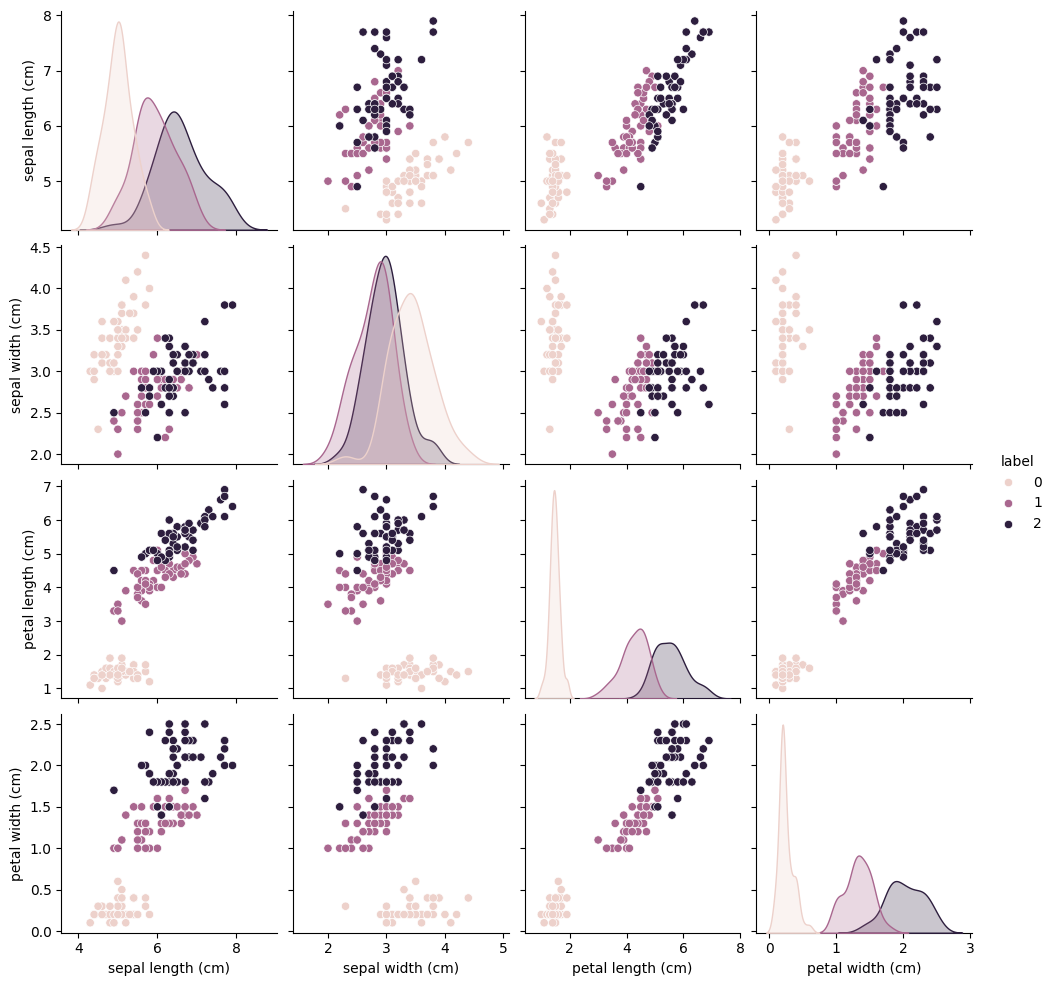

In [13]:
# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(iris_df, hue='label')
plt.show()

In [15]:
# 속성과 Target 분리
# iris_df

X = iris_df.drop('label', axis=1)
y = iris_df['label']

In [22]:
# 학습용 데이터와 테스트용 데이터로 분리
# 테스트 20%, 학습 80% , random_state=10
# TODO: YOUR_CODE_HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42, stratify=y)

In [23]:
y_train.value_counts()

label
0    40
2    40
1    40
Name: count, dtype: int64

In [26]:
# DecisionTree로 학습

# DecisionTreeClassifier 객체 생성 
dt_clf = DecisionTreeClassifier(random_state=42)

# 학습 (학습 데이터를 사용하여 fit)
# TODO: YOUR_CODE_HERE
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [27]:
#  예측

# TODO: YOUR_CODE_HERE
pred = dt_clf.predict(X_test)

In [28]:
pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

In [31]:
pred, y_test.values

(array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
        1, 1, 2, 2, 1, 0, 2, 0]),
 array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
        1, 2, 2, 1, 1, 0, 2, 0]))

In [29]:
# 성능 평가하기
# 정확도는 예측 결과가 실제 레이블 값과 얼마나 정확하게 맞는지를 평가하는 지표

from sklearn.metrics import accuracy_score

print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test,pred)))

예측 정확도: 0.9333


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [34]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,pred)

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  1,  9]])

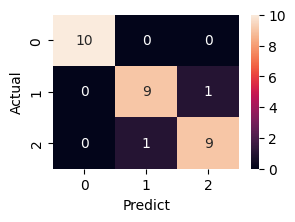

In [37]:
cm = confusion_matrix(y_test,pred, labels=[0, 1, 2])

plt.figure(figsize=(3,2))
sns.heatmap(cm, annot=True)
plt.xlabel('Predict')
plt.ylabel('Actual')
plt.show()

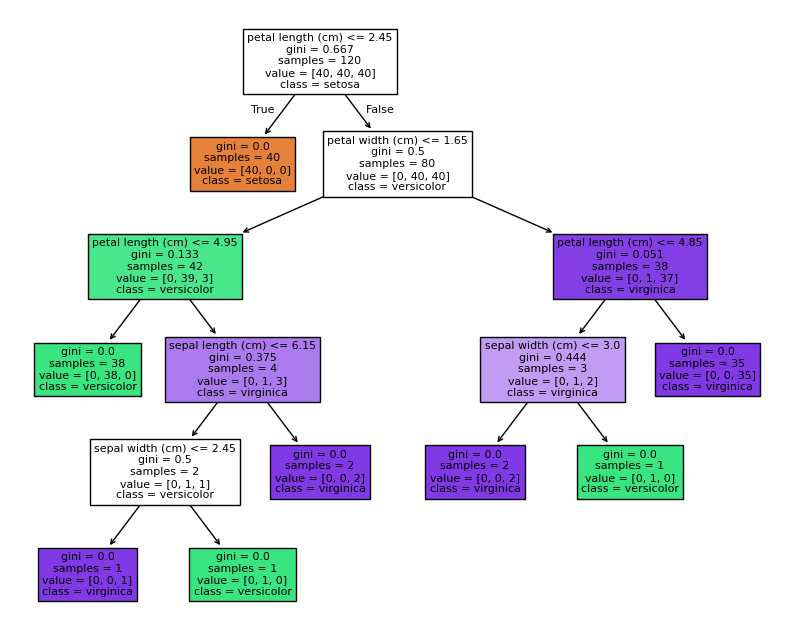

In [41]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 8))
plot_tree(dt_clf,
          feature_names = iris.feature_names,
          class_names = iris.target_names, 
          filled=True)
plt.show()

In [42]:
dt_clf.get_depth()

5

In [43]:
dt_clf.feature_importances_

array([0.00625   , 0.02916667, 0.5585683 , 0.40601504])

In [ ]:
[5, 3.5, 1.4, 0.25]

In [ ]:
# 교차검증 

In [ ]:
from sklearn.datasets import load_iris 
iris = load_iris() 
df_iris = pd.DataFrame(iris.data,
             columns = iris.feature_names,)
df_iris["label"] = iris.target
df_iris.head(3)

In [ ]:
X = df_iris.drop('label', axis=1)
y = df_iris['label']

In [ ]:
from sklearn.model_selection import train_test_split

# 학습용 데이터와 테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

In [44]:
# 훈련데이터로 교차검증 

from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = DecisionTreeClassifier()

cv_scores_accuracy = cross_val_score(model, X = X_train, y = y_train, scoring='accuracy', cv=skf)
cv_scores_f1= cross_val_score(model, X = X_train, y = y_train, scoring='f1_macro', cv=skf)

print('accuracy : ', cv_scores_accuracy, cv_scores_accuracy.mean())
print('f1 : ', cv_scores_f1, cv_scores_f1.mean())

# 학습 
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

pred = dt_clf.predict(X_test)
print(classification_report(y_test,pred))

accuracy :  [0.95833333 0.95833333 0.95833333 0.95833333 0.91666667] 0.95
f1 :  [0.95816993 0.95816993 0.95816993 0.91534392 0.91534392] 0.94103952692188
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
# 최종평가 
from sklearn.metrics import classification_report

In [ ]:
model = DecisionTreeClassifier()

In [45]:
# GridSearchCV 

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

parameters = {'max_depth':[3,4,5],
              'min_samples_split':[2,4]}

gscv = GridSearchCV(model, param_grid=parameters, cv=skf, refit=True)

gscv.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [3, 4, 5], 'min_samples_split': [2, 4]})

In [49]:
gscv.best_estimator_
gscv.best_params_
# gscv.best_score_

{'max_depth': 3, 'min_samples_split': 2}

In [50]:
pred = gscv.predict(X_test)

In [ ]:
DecisionTreeClassifier(max_depth = 3, min_samples_split = 2, random_state=42)

In [52]:
# GridSearchCV 결과확인 
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [53]:
gscv.best_estimator_

DecisionTreeClassifier(max_depth=3)

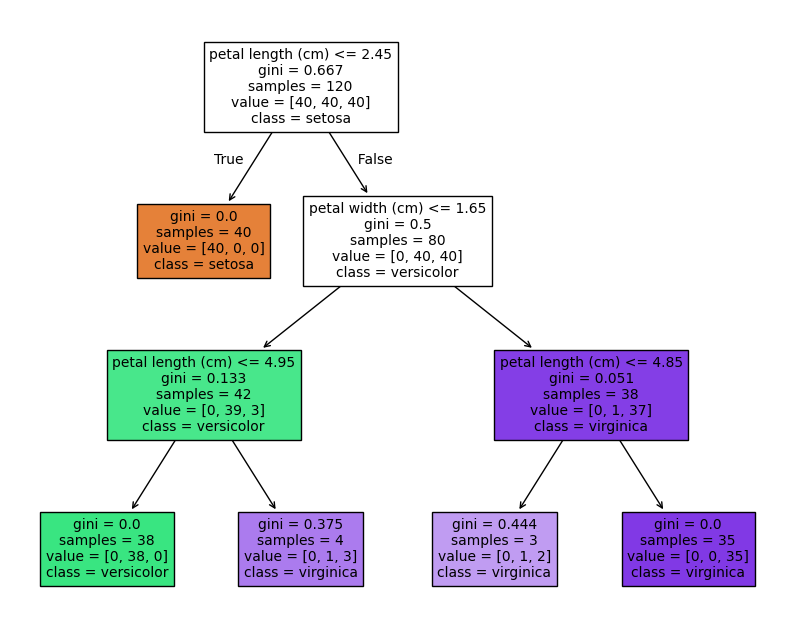

In [54]:
plt.figure(figsize=(10, 8))
plot_tree(gscv.best_estimator_,
          feature_names = iris.feature_names,
          class_names = iris.target_names, 
          filled=True)
plt.show()

In [ ]:
# 최종 테스트